# MassSpecGym Feasibility Exploration

## Purpose

This notebook evaluates whether the MassSpecGym dataset is practical for a
DSC 670 generative AI term project investigating MS/MS-to-SMILES generation.

### Questions

1. Can the dataset be loaded easily in Python?
2. What information is available for each MS/MS spectrum?
3. Is a known molecular structure (SMILES) provided for each spectrum?
4. Can the spectrum be serialized into text without manual fragment interpretation?
5. Can the target SMILES be parsed and evaluated computationally?
6. Is the resulting input/output format appropriate for OpenAI fine-tuning?

### Scope

This exploration does not attempt manual mass spectral interpretation or
complete molecular structure elucidation. Its purpose is to determine whether
existing paired spectrum-structure data can support a manageable generative
AI experiment.

In [1]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\sfnor\miniconda3\envs\gen_ai\python.exe
3.11.16 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:36:16) [MSC v.1942 64 bit (AMD64)]


In [2]:
import pandas as pd

print("pandas:", pd.__version__)

pandas: 3.0.5


In [3]:
import os
import warnings

# Suppress the Windows cache symlink warning.
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Suppress the warning about unavailable notebook progress widgets.
warnings.filterwarnings(
    "ignore",
    message=r"IProgress not found.*"
)

In [4]:
import datasets

print("datasets:", datasets.__version__)

datasets: 5.0.1


In [5]:
# Run only when setting up a new environment:
# %pip install rdkit

In [6]:
from rdkit import Chem

print("RDKit imported successfully!")

RDKit imported successfully!


In [7]:
from datasets import load_dataset

dataset = load_dataset("roman-bushuiev/MassSpecGym")

In [8]:
print(dataset)

DatasetDict({
    val: Dataset({
        features: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct', 'instrument_type', 'collision_energy', 'fold', 'simulation_challenge'],
        num_rows: 231104
    })
})


In [9]:
example = dataset["val"][0]

example

{'identifier': 'MassSpecGymID0000001',
 'mzs': '91.0542,125.0233,154.0499,155.0577,185.0961,200.107,229.0859,246.1125',
 'intensities': '0.24524524524524524,1.0,0.08008008008008008,0.35535535535535534,0.34934934934934936,0.04504504504504504,0.14214214214214213,0.7347347347347347',
 'smiles': 'COc1cc([C@H](Cc2ccccc2)NC(C)=O)oc(=O)c1',
 'inchikey': 'VFMQMACUYWGDOJ',
 'formula': 'C16H17NO4',
 'precursor_formula': 'C16H18NO4',
 'parent_mass': 287.115224,
 'precursor_mz': 288.1225,
 'adduct': '[M+H]+',
 'instrument_type': 'Orbitrap',
 'collision_energy': 30.0,
 'fold': 'train',
 'simulation_challenge': True}

In [10]:
dataset.keys()

dict_keys(['val'])

In [11]:
# What different values exist in the fold field, and how many observations belong to each?

df = dataset["val"].to_pandas()

type(df)

pandas.DataFrame

In [12]:
df["fold"].value_counts()

fold
train    194119
val       19429
test      17556
Name: count, dtype: int64

In [13]:
peaks = df["mzs"].iloc[0]

type(peaks)

str

In [14]:
peaks = df["mzs"].iloc[0]

peaks_string = peaks.split(",")

len(peaks_string)

8

In [15]:
len(df["mzs"].iloc[0].split(","))

8

In [16]:
df["mzs"].apply(lambda x:len(x.split(",")))

0           8
1           6
2          12
3          20
4           6
         ... 
231099    114
231100    191
231101     59
231102     56
231103     77
Name: mzs, Length: 231104, dtype: int64

In [17]:
df["n_peaks"] = df["mzs"].apply(lambda x: len(x.split(",")))

In [18]:
df["n_peaks"].describe()

count    231104.000000
mean         36.488633
std          48.160836
min           1.000000
25%           9.000000
50%          19.000000
75%          41.000000
max         299.000000
Name: n_peaks, dtype: float64

In [19]:
smiles = df["smiles"].iloc[0]

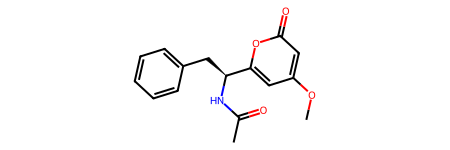

In [20]:
Chem.MolFromSmiles(smiles)

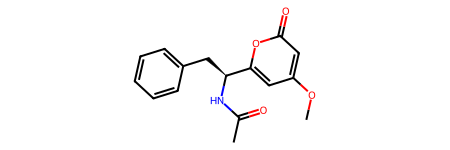

In [21]:
smiles = df["smiles"].iloc[0]

molecule = Chem.MolFromSmiles(smiles)

molecule

In [22]:
df.isna().sum().sort_values(ascending=False)

collision_energy        109358
instrument_type           5223
identifier                   0
smiles                       0
inchikey                     0
mzs                          0
intensities                  0
precursor_formula            0
formula                      0
precursor_mz                 0
parent_mass                  0
adduct                       0
fold                         0
simulation_challenge         0
n_peaks                      0
dtype: int64

In [23]:
# Percentage of missing metadata within each fold

df.groupby("fold")[["collision_energy", "instrument_type"]].agg(
    lambda column: column.isna().mean() * 100
).round(2)

,collision_energy,instrument_type
fold,,
test,42.12,2.33
train,47.66,2.23
val,48.66,2.50


In [24]:
# Count blank strings in the core spectrum and structure fields.

columns_to_check = ["mzs", "intensities", "smiles"]

df[columns_to_check].apply(
    lambda column: column.str.strip().eq("").sum()
)

mzs            0
intensities    0
smiles         0
dtype: int64

In [25]:
# Count intensity values in each spectrum.
df["n_intensities"] = df["intensities"].apply(
    lambda x: len(x.split(","))
)

# Count rows where the two lengths differ
(df["n_peaks"] != df["n_intensities"]).sum()

np.int64(0)

In [26]:
df.isna().sum().sort_values(ascending=False)

collision_energy        109358
instrument_type           5223
identifier                   0
mzs                          0
inchikey                     0
formula                      0
intensities                  0
smiles                       0
parent_mass                  0
precursor_formula            0
adduct                       0
precursor_mz                 0
fold                         0
simulation_challenge         0
n_peaks                      0
n_intensities                0
dtype: int64

In [27]:
# Select the first spectrum.
example = df.iloc[0]

# Split each string and convert each value to a decimal number.
mz_values = [float(x) for x in example["mzs"].split(",")]
intensity_values = [float(x) for x in example["intensities"].split(",")]

# Display the paired values.
spectrum = pd.DataFrame({
    "mz": mz_values,
    "intensity": intensity_values
})

spectrum

,mz,intensity
0,91.0542,0.245245
1,125.0233,1.000000
2,154.0499,0.080080
3,155.0577,0.355355
4,185.0961,0.349349
5,200.1070,0.045045
6,229.0859,0.142142
7,246.1125,0.734735


In [28]:
# Define a function that reports whether conversion succeeds.

def can_parse_numbers(text):
    try:
        values = [float(x) for x in text.split(",")]
        return True
    except(ValueError, TypeError, AttributeError):
        return False

In [29]:
# Create two columns recording whether conversion succeeds.

df["mzs_parseable"] = df["mzs"].apply(can_parse_numbers)
df["intensities_parseable"] = df["intensities"].apply(can_parse_numbers)

# Count successful and unsuccessful conversions.

df[["mzs_parseable", "intensities_parseable"]].apply(
    lambda column: column.value_counts()
)

,mzs_parseable,intensities_parseable
True,231104,231104


In [30]:
df[["mzs_parseable", "intensities_parseable"]].head()

,mzs_parseable,intensities_parseable
0,True,True
1,True,True
2,True,True
3,True,True
4,True,True


In [31]:
import math

def all_values_finite(text):
    values = [float(x) for x in text.split(",")]
    return all(math.isfinite(value) for value in values)

In [32]:
df["mzs_finite"] = df["mzs"].apply(all_values_finite)
df["intensities_finite"] = df["intensities"].apply(all_values_finite)

df[["mzs_finite", "intensities_finite"]].apply(
    lambda column: column.value_counts()
)

,mzs_finite,intensities_finite
True,231104,231104


In [33]:
def all_values_positive(text):
    values = [float(x) for x in text.split(",")]
    return all(value > 0 for value in values)

def all_values_nonnegative(text):
    values = [float(x) for x in text.split(",")]
    return all(value >= 0 for value in values)

In [34]:
df["mzs_positive"] = df["mzs"].apply(all_values_positive)
df["intensities_nonnegative"] = df["intensities"].apply(all_values_nonnegative
)

df[["mzs_positive", "intensities_nonnegative"]].apply(
    lambda column: column.value_counts()
)

,mzs_positive,intensities_nonnegative
True,231104,231104


In [35]:
def has_positive_signal(text):
    values = [float(x) for x in text.split(",")]
    return any(value > 0 for value in values)

df["has_positive_signal"] = df["intensities"].apply(
    has_positive_signal
)

df["has_positive_signal"].value_counts()

has_positive_signal
True    231104
Name: count, dtype: int64

In [36]:
def smiles_is_valid(smiles):
    molecule = Chem.MolFromSmiles(smiles)
    return molecule is not None and molecule.GetNumAtoms() > 0

In [37]:
# Run the function on each SMILES and store the results

df["smiles_valid"] = df["smiles"].apply(smiles_is_valid)

# Display how many passed or failed
df["smiles_valid"].value_counts()

smiles_valid
True    231104
Name: count, dtype: int64

In [38]:
df.groupby("fold").agg(
    spectra=("identifier", "size"),
    unique_molecules=("inchikey", "nunique")
)

,spectra,unique_molecules
fold,,
test,17556,2998
train,194119,22746
val,19429,3185


In [39]:
# Count how many different folds each molecule identifier appears in.

folds_per_molecule = df.groupby("inchikey")["fold"].nunique()

# Count molecule identifiers appearing in more than one fold.

(folds_per_molecule > 1).sum()

np.int64(0)